In [1]:
import pandas as pd
import numpy as np 
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:,0].tolist()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {len(feature_names)}")

Train: (380980, 30), Test: (93987, 30)
Features: 30


In [3]:

# 1. Point MLflow to a local SQLite database backend
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# 2. Set your experiment name (this will now work)
mlflow.set_experiment(experiment_name="credit-fraud-detection")

print('Mlflow tracking ready')
print("Run 'mlflow ui --backend-store-uri sqlite:///mlflow.db' in terminal to view dashboard")

2026/06/26 00:39:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/26 00:39:32 INFO mlflow.store.db.utils: Updating database tables
2026/06/26 00:39:34 INFO mlflow.tracking.fluent: Experiment with name 'credit-fraud-detection' does not exist. Creating a new experiment.


Mlflow tracking ready
Run 'mlflow ui --backend-store-uri sqlite:///mlflow.db' in terminal to view dashboard


In [4]:
mlflow.get_tracking_uri()

'sqlite:///mlflow.db'

In [5]:
mlflow.VERSION

'3.14.0'

In [6]:
def evaluate_model(model, X_test,y_test,model_name):
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]

    f1=f1_score(y_test, y_pred)
    roc_auc=roc_auc_score(y_test, y_prob)
    pr_auc=average_precision_score(y_test, y_prob)

    print(f'\n{'='*40}')
    print(f"Model: {model_name}")
    print(f'\n{'='*40}')
    print(f'F1 Score : {f1:.4f}')
    print(f'Roc_auc Score : {roc_auc:.4f}')
    print(f'PR-AUC : {pr_auc:.4f}')
    print(classification_report(y_test,y_pred,target_names=['Legitimate','Fraud']))

    #confusion matrix
    cm=confusion_matrix(y_test,y_pred)
    disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Legitimate','Fraud'])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'../models/{model_name}_confusion_matrix.png')
    plt.show()

    return {'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
            'fig': fig, 'y_pred': y_pred, 'y_prob': y_prob}



Model: LogisticRegression

F1 Score : 0.1066
Roc_auc Score : 0.9730
PR-AUC : 0.7557
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     93825
       Fraud       0.06      0.93      0.11       162

    accuracy                           0.97     93987
   macro avg       0.53      0.95      0.55     93987
weighted avg       1.00      0.97      0.98     93987



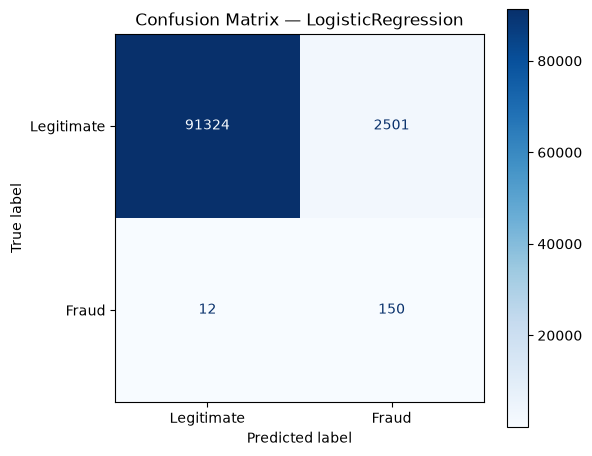

2026/06/26 00:39:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logged to Mlflow


In [7]:
import os 
os.makedirs('../models',exist_ok=True)


with mlflow.start_run(run_name='LogisticRegression'):

    #Train
    params={'max_iter': 1000,'random_state': 7,'C': 0.1}
    lr=LogisticRegression(**params)
    lr.fit(X_train,y_train)

    #Evaluate
    metrics=evaluate_model(lr,X_test,y_test,'LogisticRegression')

    mlflow.log_params(params)
    mlflow.log_metric('F1_score',metrics['f1'])
    mlflow.log_metric('roc_auc',metrics['roc_auc'])
    mlflow.log_metric('pr_auc',metrics['pr_auc'])
    mlflow.log_artifact(f'../models/LogisticRegression_confusion_matrix.png')
    mlflow.sklearn.log_model(lr,'model')

    print('\nLogged to Mlflow')




Model: RandomForest

F1 Score : 0.5663
Roc_auc Score : 0.9872
PR-AUC : 0.8325
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     93825
       Fraud       0.42      0.87      0.57       162

    accuracy                           1.00     93987
   macro avg       0.71      0.93      0.78     93987
weighted avg       1.00      1.00      1.00     93987



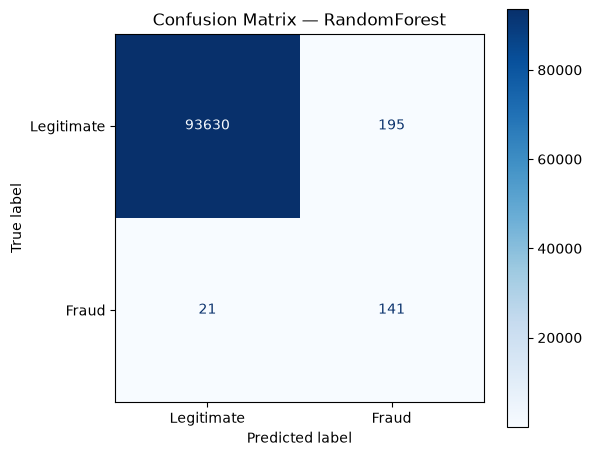

2026/06/26 00:39:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logged to Mlflow


In [8]:

with mlflow.start_run(run_name='RandomForest'):

    #Train
    params={'n_estimators': 100,'random_state': 7,'n_jobs': -1, 'max_depth': 10}
    rf=RandomForestClassifier(**params)
    rf.fit(X_train,y_train)

    #Evaluate
    metrics=evaluate_model(rf,X_test,y_test,'RandomForest')

    mlflow.log_params(params)
    mlflow.log_metric('F1_score',metrics['f1'])
    mlflow.log_metric('roc_auc',metrics['roc_auc'])
    mlflow.log_metric('pr_auc',metrics['pr_auc'])
    mlflow.log_artifact(f'../models/RandomForest_confusion_matrix.png')
    mlflow.sklearn.log_model(lr,'model')

    print('\nLogged to Mlflow')




Model: XGBoost

F1 Score : 0.7688
Roc_auc Score : 0.9849
PR-AUC : 0.8655
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     93825
       Fraud       0.70      0.85      0.77       162

    accuracy                           1.00     93987
   macro avg       0.85      0.93      0.88     93987
weighted avg       1.00      1.00      1.00     93987



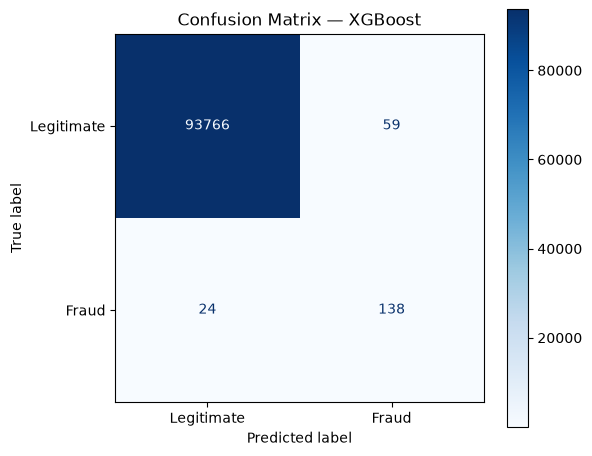

2026/06/26 00:40:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logged to Mlflow


In [9]:



with mlflow.start_run(run_name='XGBoost'):

    #Train
    params={'n_estimators': 100,'random_state': 7,'learning_rate': 0.1, 'max_depth': 10,'eval_metric':'aucpr', 'use_lable_encoder': False,'subsample': 0.8}
    xgb=XGBClassifier(**params)
    xgb.fit(X_train,y_train)

    #Evaluate
    metrics=evaluate_model(xgb,X_test,y_test,'XGBoost')

    mlflow.log_params(params)
    mlflow.log_metric('F1_score',metrics['f1'])
    mlflow.log_metric('roc_auc',metrics['roc_auc'])
    mlflow.log_metric('pr_auc',metrics['pr_auc'])
    mlflow.log_artifact(f'../models/XGBoost_confusion_matrix.png')
    mlflow.sklearn.log_model(lr,'model')

    print('\nLogged to Mlflow')




Model: LightGBM

F1 Score : 0.4315
Roc_auc Score : 0.9792
PR-AUC : 0.7623
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     93825
       Fraud       0.28      0.90      0.43       162

    accuracy                           1.00     93987
   macro avg       0.64      0.95      0.71     93987
weighted avg       1.00      1.00      1.00     93987



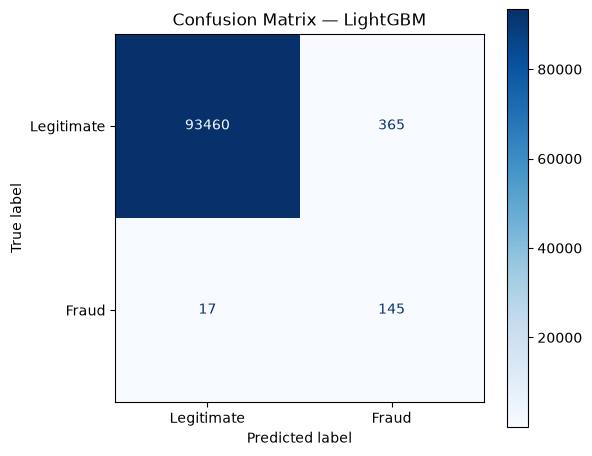

2026/06/26 00:40:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logged to Mlflow


In [10]:

with mlflow.start_run(run_name='LightGBM'):

    #Train
    params={'n_estimators': 100,'random_state': 7,'learning_rate': 0.05,'n_jobs': -1, 'max_depth': 10,'num_leaves':31, 'verbose': -1}
    lgbm=LGBMClassifier(**params)
    lgbm.fit(X_train,y_train)

    #Evaluate
    metrics=evaluate_model(lgbm,X_test,y_test,'LightGBM')

    mlflow.log_params(params)
    mlflow.log_metric('F1_score',metrics['f1'])
    mlflow.log_metric('roc_auc',metrics['roc_auc'])
    mlflow.log_metric('pr_auc',metrics['pr_auc'])
    mlflow.log_artifact(f'../models/LightGBM_confusion_matrix.png')
    mlflow.sklearn.log_model(lr,'model')

    print('\nLogged to Mlflow')



                        F1  ROC_AUC  PR_AUc
LogisticRegression  0.1066   0.9730  0.7557
Random Forest       0.5663   0.9872  0.8325
XGBoost             0.7688   0.9849  0.8655
LightGBM            0.4315   0.9792  0.7623


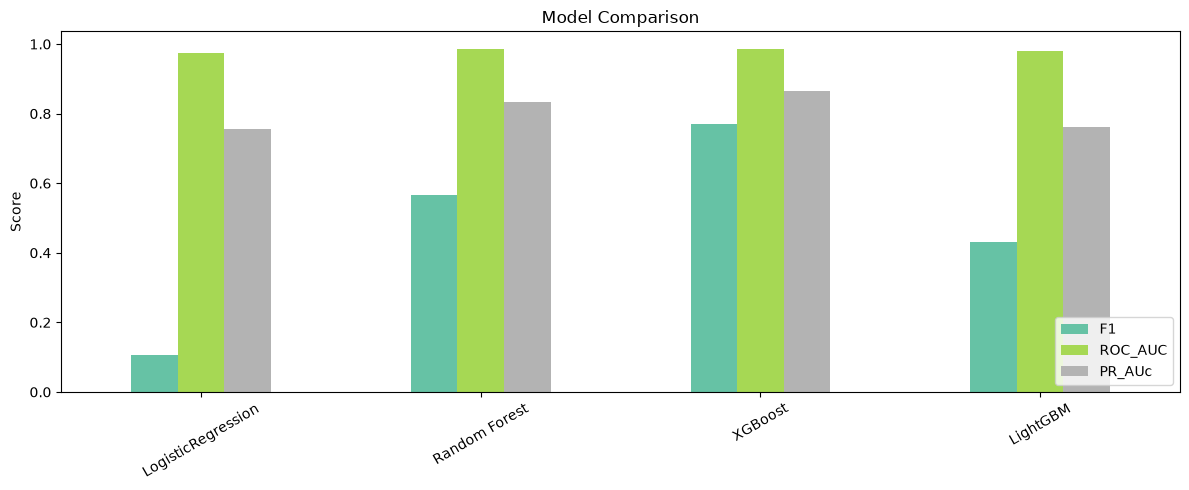

In [11]:
results={
    'LogisticRegression':{
        'F1':f1_score(y_test,lr.predict(X_test)),
        'ROC_AUC':roc_auc_score(y_test,lr.predict_proba(X_test)[:,1]),
        'PR_AUc':average_precision_score(y_test,lr.predict_proba(X_test)[:,1])
    },
    'Random Forest':{
        'F1':f1_score(y_test,rf.predict(X_test)),
        'ROC_AUC':roc_auc_score(y_test,rf.predict_proba(X_test)[:,1]),
        'PR_AUc':average_precision_score(y_test,rf.predict_proba(X_test)[:,1])
    },
    'XGBoost':{
        'F1':f1_score(y_test,xgb.predict(X_test)),
        'ROC_AUC':roc_auc_score(y_test,xgb.predict_proba(X_test)[:,1]),
        'PR_AUc':average_precision_score(y_test,xgb.predict_proba(X_test)[:,1])
    },
    'LightGBM':{
        'F1':f1_score(y_test,lgbm.predict(X_test)),
        'ROC_AUC':roc_auc_score(y_test,lgbm.predict_proba(X_test)[:,1]),
        'PR_AUc':average_precision_score(y_test,lgbm.predict_proba(X_test)[:,1])
    }
}

results_df= pd.DataFrame(results).T.round(4)  #here round(4) just make the values round off to 4 digits

print(results_df)

results_df.plot(kind='bar',figsize=(12,5),colormap='Set2')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../models/model_comparion.png')
plt.show()

In [12]:
import joblib

best_model=xgb
joblib.dump(best_model,'../models/best_model.pkl')
print('Best model saved to models/best_model.pkl')

Best model saved to models/best_model.pkl
